<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 50 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Server Traffic Spikes: the Poisson 🖥️</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Requests arrive at a server one after another, at a steady average rate. Counts per second are the Poisson distribution. We fit lambda, confirm the mean-equals-variance signature, and size the risk of a load-breaching spike.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/it_server_traffic.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"it_server_traffic.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,timestamp,server_id,api_endpoint,requests_per_second
0,2026-06-01 12:00:00,SRV_NODE_A,/v1/checkout,11
1,2026-06-01 12:00:01,SRV_NODE_A,/v1/users,8
2,2026-06-01 12:00:02,SRV_NODE_B,/v1/users,8
3,2026-06-01 12:00:03,SRV_NODE_A,/v1/products,11
4,2026-06-01 12:00:04,SRV_NODE_B,/v1/users,10


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · FIT lambda, CHECK THE SIGNATURE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Mean equals variance</div>
<div style="color:#4a5578;margin-top:6px">The Poisson counts events in a fixed interval at average rate lambda. Its fingerprint: mean = variance = lambda. If the data shows that, the Poisson is the right model.</div>
</div>

In [2]:
x = df["requests_per_second"]
lam = x.mean()
print(f"observations     : {len(x):,}")
print(f"mean (lambda hat) : {x.mean():.3f}")
print(f"variance          : {x.var():.3f}")
print(f"-> mean ~ variance, the Poisson signature ({x.var()/x.mean():.3f} ratio)")

observations     : 1,000
mean (lambda hat) : 12.007
variance          : 11.691
-> mean ~ variance, the Poisson signature (0.974 ratio)


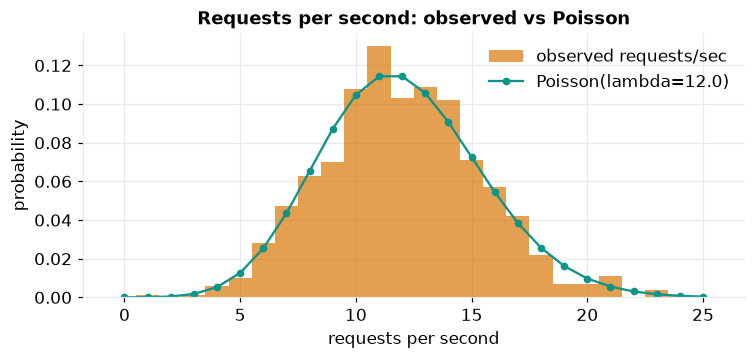

In [3]:
fig,ax=plt.subplots(figsize=(7,3.4))
kmax=int(x.max())+1; k=np.arange(0,kmax+1)
ax.hist(x,bins=np.arange(-0.5,kmax+1.5),density=True,color=AMBER,alpha=0.7,label="observed requests/sec")
ax.plot(k, stats.poisson.pmf(k,lam),"o-",color=TEAL,ms=4,label=f"Poisson(lambda={lam:.1f})")
ax.set_xlabel("requests per second"); ax.set_ylabel("probability"); ax.set_title("Requests per second: observed vs Poisson"); ax.legend()
plt.tight_layout(); plt.show()

Mean and variance are both about **12**, the Poisson signature, and the PMF tracks the observed counts closely. A single rate lambda &#8776; 12 requests/second describes the whole traffic distribution.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · THE SPIKE RISK</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Complementary CDF for the tail</div>
<div style="color:#4a5578;margin-top:6px">Capacity planning lives in the tail. If the server degrades above 20 requests/second, the breach probability is the complementary CDF P(X > 20).</div>
</div>

In [4]:
for thr in [15,18,20,22]:
    print(f"P(X > {thr}) = {stats.poisson.sf(thr,lam):.4f}   (observed {(x>thr).mean():.4f})")
print(f"\n95th percentile of load = {stats.poisson.ppf(0.95,lam):.0f} requests/sec")
print(f"99th percentile of load = {stats.poisson.ppf(0.99,lam):.0f} requests/sec")

P(X > 15) = 0.1561   (observed 0.1510)
P(X > 18) = 0.0376   (observed 0.0300)
P(X > 20) = 0.0117   (observed 0.0160)
P(X > 22) = 0.0031   (observed 0.0050)

95th percentile of load = 18 requests/sec
99th percentile of load = 21 requests/sec


A breach above 20 requests/second happens about **1.2%** of the time under the Poisson, P(X &gt; 20) &#8776; 0.012, close to the 1.6% seen in the data. The 99th percentile load is about 21 requests/second, the number to provision against. The tail, not the average, drives capacity.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · WHY POISSON? MANY CHANCES, EACH RARE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The binomial limit</div>
<div style="color:#4a5578;margin-top:6px">The Poisson is the limit of a binomial with huge n and tiny p (np = lambda). Each of millions of users might hit the server in a given second, but each is unlikely, exactly the Poisson setup.</div>
</div>

In [5]:
n, p = 100000, lam/100000      # many users, each with a tiny per-second hit probability
k=np.arange(0,int(x.max())+1)
binom = stats.binom.pmf(k,n,p); pois = stats.poisson.pmf(k,lam)
print(f"max |Binomial(100000, lambda/100000) - Poisson(lambda)| = {np.abs(binom-pois).max():.6f}")
rng=np.random.default_rng(50); sim=rng.poisson(lam,size=200_000)
print(f"simulated mean {sim.mean():.2f}, var {sim.var():.2f}, P(>20) {(sim>20).mean():.4f}")

max |Binomial(100000, lambda/100000) - Poisson(lambda)| = 0.000007
simulated mean 12.02, var 11.97, P(>20) 0.0118


A binomial with 100,000 users each hitting at probability &#955;/100,000 is indistinguishable from the Poisson, differing by less than a millionth. That is the Poisson story: a vast number of independent chances, each unlikely, collapsing to a single rate &#955; that is both the mean and the variance of the count.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Server requests per second are Poisson. We fit lambda &#8776; 12, confirmed mean = variance, computed the spike-breach risk P(X &gt; 20) &#8776; 1.2% and the 99th-percentile load, and saw the Poisson emerge as the large-n, small-p limit of the binomial. Capacity is a tail question, and the Poisson answers it.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>